## Naïve Bayes in Machine Learning

Naïve Bayes is a supervised learning algorithm based on Bayes' theorem with a "naïve" assumption of independence among features. It's particularly popular for text classification and spam detection due to its simplicity, speed, and effectiveness. Despite its simplifying assumption, it often performs surprisingly well in practice.

### Bayes' Theorem

The core of Naïve Bayes is Bayes' theorem, which describes the probability of an event, based on prior knowledge of conditions that might be related to the event. Mathematically, it's expressed as:

$$P(A|B) = \frac{P(B|A) P(A)}{P(B)}$$

Where:
- $P(A|B)$ is the posterior probability: the probability of hypothesis A given the evidence B.
- $P(B|A)$ is the likelihood: the probability of evidence B given that hypothesis A is true.
- $P(A)$ is the prior probability: the probability of hypothesis A being true (regardless of the evidence).
- $P(B)$ is the marginal probability: the probability of the evidence B (regardless of the hypothesis).

### Naïve Bayes Assumption

The "naïve" part of the algorithm comes from the assumption that all features are independent of each other given the class label. This means:

$$P(x_1, x_2, ..., x_n | C) = P(x_1 | C) * P(x_2 | C) * ... * P(x_n | C)$$

Where:
- $C$ represents the class label.
- $x_1, x_2, ..., x_n$ are the features.

Combining this with Bayes' theorem for classification, we want to find the class $C_k$ that maximizes $P(C_k | x_1, ..., x_n)$:

$$P(C_k | x_1, ..., x_n) = \frac{P(x_1 | C_k) P(x_2 | C_k) ... P(x_n | C_k) P(C_k)}{P(x_1, ..., x_n)}$$

Since $P(x_1, ..., x_n)$ is constant for all classes, we only need to maximize the numerator:

$$\text{class} = \text{argmax}_{C_k} [P(C_k) \prod_{i=1}^{n} P(x_i | C_k)]$$

### Types of Naïve Bayes Classifiers

The specific type of Naïve Bayes classifier depends on the underlying distribution assumed for the features ($P(x_i | C_k)$).

1.  **Gaussian Naïve Bayes:**
    -   **Assumption:** Features follow a Gaussian (normal) distribution.
    -   **Use Case:** Suitable for continuous features. The likelihood of the features is assumed to be a Gaussian probability density function.
    -   **Formula:** The conditional probability $P(x_i | C_k)$ is calculated using the mean and standard deviation of feature $x_i$ for each class $C_k$.:
        $$P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma^2_{C_k}}} \exp\left(-\frac{(x_i - \mu_{C_k})^2}{2\sigma^2_{C_k}}\right)$$
        where $\mu_{C_k}$ is the mean and $\sigma^2_{C_k}$ is the variance of feature $x_i$ in class $C_k$.

2.  **Multinomial Naïve Bayes:**
    -   **Assumption:** Features represent counts (e.g., word counts in a document) or frequencies.
    -   **Use Case:** Very popular for text classification (e.g., spam detection, sentiment analysis), where features are typically word occurrences or term frequencies.
    -   **Formula:** It uses a multinomial distribution for the likelihood. The probability of feature $x_i$ appearing in class $C_k$ is calculated as:
        $$P(x_i | C_k) = \frac{\text{count}(x_i, C_k) + \alpha}{\text{count}(C_k) + \alpha \times n}$$
        where $\text{count}(x_i, C_k)$ is the number of times feature $x_i$ appears in class $C_k$, $\text{count}(C_k)$ is the total count of all features in class $C_k$, $n$ is the total number of unique features, and $\alpha$ is a smoothing parameter (Laplace/Lidstone smoothing, typically $\alpha=1$ to prevent zero probabilities).

3.  **Bernoulli Naïve Bayes:**
    -   **Assumption:** Features are binary (boolean) values, indicating the presence or absence of a particular feature.
    -   **Use Case:** Also suitable for text classification, especially when features are binary indicators of word presence/absence rather than counts. Often used for document classification where the focus is on whether a word exists in a document, not how many times.
    -   **Formula:** For each feature $x_i$ and class $C_k$, two probabilities are calculated: $P(x_i=1 | C_k)$ (probability of feature $x_i$ being present) and $P(x_i=0 | C_k)$ (probability of feature $x_i$ being absent).
        $$P(x_i | C_k) = p_{ik} \text{ if } x_i=1 \text{ else } (1-p_{ik})$$
        where $p_{ik}$ is the probability that feature $x_i$ occurs in a sample belonging to class $C_k$.

### Advantages of Naïve Bayes

*   **Simplicity and Speed:** Easy to implement and computationally very efficient.
*   **Scalability:** Performs well with large datasets.
*   **Good Performance with Text Data:** Highly effective for text classification tasks.
*   **Handles High-Dimensional Data:** Can handle a large number of features.
*   **Less Training Data Needed:** Can perform well even with relatively small training datasets compared to more complex algorithms.

### Disadvantages of Naïve Bayes

*   **Strong Independence Assumption:** The

# Program 1: Iris Flower Classification using Gaussian Naïve Bayes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

In [ ]:
iris=load_iris()
X=iris.data[:,:2]
y=iris.target

print("Feature Names:", iris.feature_names)
print("Target Names:", iris.target_names)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# ------------------------------------
# Confusion Matrix
# ------------------------------------

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9

Confusion Matrix
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


In [ ]:

# ------------------------------------
# Classification Report
# ------------------------------------

print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))



Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.78      0.82         9
   virginica       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [ ]:
# Predict New Flower
# ------------------------------------

sample = [[5.1,3.5]]

prediction = model.predict(sample)

print("\nPrediction:", iris.target_names[prediction][0])



Prediction: setosa


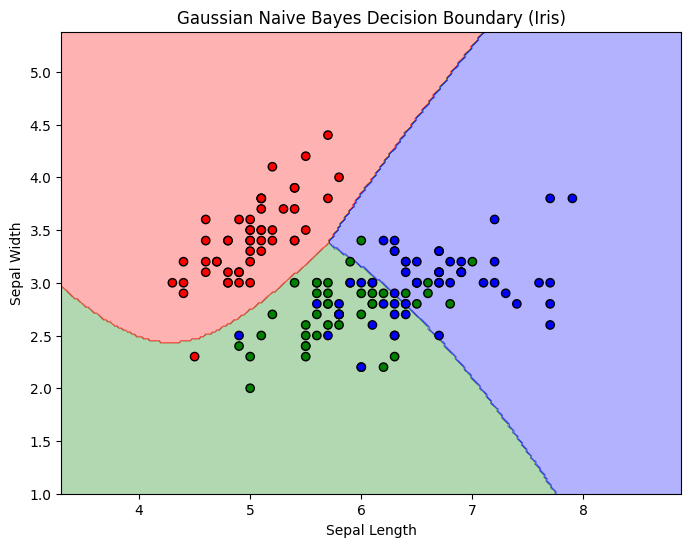

In [ ]:
# Visualization
# ------------------------------------

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=ListedColormap(("red","green","blue"))
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolor='k',
    cmap=ListedColormap(("red","green","blue"))
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Gaussian Naive Bayes Decision Boundary (Iris)")
plt.show()

# Program 2: Wine Classification using Gaussian Naïve Bayes

In [ ]:
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
wine=load_wine()
X=wine.data
y=wine.target

print("Feature Names:", wine.feature_names)
print("Target Names:", wine.target_names)



Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target Names: ['class_0' 'class_1' 'class_2']


In [ ]:
for feature in wine.feature_names:
    print(feature)

print("\nTarget Classes")

print(wine.target_names)

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline

Target Classes
['class_0' 'class_1' 'class_2']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)



In [ ]:
# Accuracy
# ------------------------------------

print("\nAccuracy")

print(accuracy_score(y_test,y_pred))

# ------------------------------------
# Confusion Matrix
# ------------------------------------

print("\nConfusion Matrix")

print(confusion_matrix(y_test,y_pred))


Accuracy
1.0

Confusion Matrix
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [ ]:
print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

# ------------------------------------
# Predict New Wine
# ------------------------------------

sample = [X[0]]

prediction = model.predict(sample)

print("\nPredicted Class:", wine.target_names[prediction][0])


Classification Report
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Predicted Class: class_0


# Program 3: Text Classification using Multinomial Naïve Bayes

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Prepare Sample Text Data

We'll create a small dataset of text documents and their corresponding categories (labels). In a real-world scenario, this data would come from a corpus of text documents.

In [ ]:
# Sample documents and their categories
documents = [
    "Viagra is a pill to treat erectile dysfunction.",
    "Free Viagra now!!! Click here to get your pills.",
    "Machine learning is a field of artificial intelligence.",
    "Buy cheap pills and get rich quick.",
    "NLP stands for Natural Language Processing.",
    "Get your free lottery ticket and win big.",
    "Artificial intelligence is transforming the world.",
    "Learn machine learning with Python.",
    "Spam email with pills offer.",
    "Email classification is a key application of NLP."
]

# Corresponding labels (0 for 'not spam', 1 for 'spam')
labels = [0, 1, 0, 1, 0, 1, 0, 0, 1, 0]

# Display the data
for doc, label in zip(documents, labels):
    print(f"Document: '{doc}' \t\t Label: {label} ({'Spam' if label == 1 else 'Not Spam'})")

Document: 'Viagra is a pill to treat erectile dysfunction.' 		 Label: 0 (Not Spam)
Document: 'Free Viagra now!!! Click here to get your pills.' 		 Label: 1 (Spam)
Document: 'Machine learning is a field of artificial intelligence.' 		 Label: 0 (Not Spam)
Document: 'Buy cheap pills and get rich quick.' 		 Label: 1 (Spam)
Document: 'NLP stands for Natural Language Processing.' 		 Label: 0 (Not Spam)
Document: 'Get your free lottery ticket and win big.' 		 Label: 1 (Spam)
Document: 'Artificial intelligence is transforming the world.' 		 Label: 0 (Not Spam)
Document: 'Learn machine learning with Python.' 		 Label: 0 (Not Spam)
Document: 'Spam email with pills offer.' 		 Label: 1 (Spam)
Document: 'Email classification is a key application of NLP.' 		 Label: 0 (Not Spam)


### 2. Convert Text Data to Numerical Features

Multinomial Naïve Bayes expects numerical feature vectors, typically word counts or TF-IDF values. We'll use `CountVectorizer` to convert our text documents into a matrix of token counts.

In [ ]:
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the documents into a document-term matrix
X_text = vectorizer.fit_transform(documents)

# Convert labels to a NumPy array
y_text = np.array(labels)

print("Feature names (words in vocabulary):")
print(vectorizer.get_feature_names_out())
print("\nShape of the document-term matrix:", X_text.shape)
print("\nSample of the document-term matrix (sparse format):\n", X_text)

Feature names (words in vocabulary):
['and' 'application' 'artificial' 'big' 'buy' 'cheap' 'classification'
 'click' 'dysfunction' 'email' 'erectile' 'field' 'for' 'free' 'get'
 'here' 'intelligence' 'is' 'key' 'language' 'learn' 'learning' 'lottery'
 'machine' 'natural' 'nlp' 'now' 'of' 'offer' 'pill' 'pills' 'processing'
 'python' 'quick' 'rich' 'spam' 'stands' 'the' 'ticket' 'to'
 'transforming' 'treat' 'viagra' 'win' 'with' 'world' 'your']

Shape of the document-term matrix: (10, 47)

Sample of the document-term matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 67 stored elements and shape (10, 47)>
  Coords	Values
  (0, 42)	1
  (0, 17)	1
  (0, 29)	1
  (0, 39)	1
  (0, 41)	1
  (0, 10)	1
  (0, 8)	1
  (1, 42)	1
  (1, 39)	1
  (1, 13)	1
  (1, 26)	1
  (1, 7)	1
  (1, 15)	1
  (1, 14)	1
  (1, 46)	1
  (1, 30)	1
  (2, 17)	1
  (2, 23)	1
  (2, 21)	1
  (2, 11)	1
  (2, 27)	1
  (2, 2)	1
  (2, 16)	1
  (3, 14)	1
  (3, 30)	1
  :	:
  (5, 43)	1
  (5, 3)	1
  (6, 17)	1


### 3. Split Data into Training and Testing Sets

We split the data to evaluate the model's performance on unseen data.

In [ ]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.3,
    random_state=42,
    stratify=y_text # Maintain the proportion of labels in train and test sets
)

### 4. Train the Multinomial Naïve Bayes Classifier

Now, we initialize and train our `MultinomialNB` model.

In [ ]:
model_mnb = MultinomialNB()
model_mnb.fit(X_train_text, y_train_text)

y_pred_text = model_mnb.predict(X_test_text)

### 5. Evaluate the Model

We'll use accuracy, confusion matrix, and a classification report to assess the model's performance.

In [ ]:
print("\nAccuracy:", accuracy_score(y_test_text, y_pred_text))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_text, y_pred_text))

print("\nClassification Report:")
print(classification_report(
    y_test_text,
    y_pred_text,
    target_names=['Not Spam', 'Spam']
))


Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### 6. Predict on New Text

Let's see how the trained model classifies a new, unseen text.

In [ ]:
new_text = ["Free money and pills now!"]

# Vectorize the new text using the *same* vectorizer used for training
new_text_vectorized = vectorizer.transform(new_text)

# Predict the class
prediction_new_text = model_mnb.predict(new_text_vectorized)

print(f"\nNew text: '{new_text[0]}'\nPredicted class: {prediction_new_text[0]} ({'Spam' if prediction_new_text[0] == 1 else 'Not Spam'})")

new_text_2 = ["What is the best way to learn machine learning?"]
new_text_vectorized_2 = vectorizer.transform(new_text_2)
prediction_new_text_2 = model_mnb.predict(new_text_vectorized_2)

print(f"\nNew text: '{new_text_2[0]}'\nPredicted class: {prediction_new_text_2[0]} ({'Spam' if prediction_new_text_2[0] == 1 else 'Not Spam'})")


New text: 'Free money and pills now!'
Predicted class: 1 (Spam)

New text: 'What is the best way to learn machine learning?'
Predicted class: 0 (Not Spam)


## TF-IDF vs. CountVectorizer for Text Classification

Both `CountVectorizer` and TF-IDF (Term Frequency-Inverse Document Frequency) are fundamental techniques for converting raw text into numerical feature vectors that machine learning models can understand. However, they capture different aspects of word importance, which makes them suitable for different scenarios.

### 1. CountVectorizer

*   **What it does:** `CountVectorizer` simply counts the occurrences of each word in a document. It creates a vocabulary of all unique words in the corpus and then, for each document, it generates a vector where each element represents the count of a specific word from the vocabulary.

*   **Feature Representation:** The features are raw integer counts.

*   **Emphasis:** It primarily focuses on the **frequency** of words within a document. A word appearing more often in a document will have a higher count in that document's vector.

*   **Pros:**
    *   **Simplicity:** Easy to understand and implement.
    *   **Captures direct frequency:** Useful when the sheer number of times a word appears is a strong indicator (e.g., in some spam detection where certain words are repeated excessively).
    *   **No information loss:** Retains the absolute frequency of terms.

*   **Cons:**
    *   **Ignores word importance:** It treats all words equally in terms of their potential to discriminate between documents. Common words (like "the", "is", "a") that appear frequently across all documents will have high counts but might not carry much meaningful information for classification.
    *   **Can be noisy:** High counts of common, uninformative words can dominate the feature vector and potentially mislead classifiers.

*   **Example:**
    *   Document 1: "The cat sat on the mat."
    *   Document 2: "The dog sat on the log."

    Counts for "the" would be high in both, but "cat" and "dog" are more distinguishing. `CountVectorizer` would just report the counts.

### 2. TF-IDF (Term Frequency-Inverse Document Frequency)

*   **What it does:** TF-IDF goes a step further than `CountVectorizer`. It not only considers the frequency of a word within a document (Term Frequency - TF) but also its rarity across the entire corpus (Inverse Document Frequency - IDF).

    *   **Term Frequency (TF):** Similar to `CountVectorizer`, it measures how frequently a term appears in a document. Often normalized (e.g., raw count, log normalization, or augmented frequency).
    *   **Inverse Document Frequency (IDF):** Measures how important a term is. It's calculated as $\log \left(\frac{N}{df_t}\right)$, where $N$ is the total number of documents and $df_t$ is the number of documents containing term $t$. The rarer a term is across the corpus, the higher its IDF score.
    *   **TF-IDF Score:** TF-IDF is the product of TF and IDF: TF-IDF = TF * IDF. This score increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus.

*   **Feature Representation:** The features are floating-point numbers (weights).

*   **Emphasis:** It emphasizes words that are **frequent in a specific document but rare across the entire collection of documents.** This helps to filter out common words that carry little discriminative power (e.g., stop words).

*   **Pros:**
    *   **Discriminative power:** Effectively highlights words that are important and specific to a particular document or class.
    *   **Reduces impact of common words:** By incorporating IDF, it gives less weight to words that appear very frequently everywhere, which are usually not very informative for classification.
    *   **Better for many classification tasks:** Often performs better than `CountVectorizer` for tasks like topic modeling, information retrieval, and many types of text classification because it focuses on meaningful terms.

*   **Cons:**
    *   **More complex:** Computationally a bit more involved than simple counting.
    *   **Context blindness:** Like `CountVectorizer`, it doesn't understand word semantics or context (e.g., "apple" as a fruit vs. "Apple" as a company).

### Key Differences Summarized

| Feature             | `CountVectorizer`                                   | TF-IDF                                                              |
| :------------------ | :-------------------------------------------------- | :------------------------------------------------------------------ |
| **Output**          | Raw frequency counts                                | Weighted scores (TF * IDF)                                          |
| **Word Importance** | Assumes all words are equally important             | Assigns higher scores to rare, discriminative words                 |
| **Common Words**    | High counts for common words                        | Low scores for common words that appear across many documents       |
| **Use Case**        | Basic frequency analysis, simple models, when raw counts are meaningful | More sophisticated classification, information retrieval, spam detection, sentiment analysis |
| **Effectiveness**   | Good baseline, but can be noisy                     | Often performs better by highlighting more important features       |

### When to Use Which?

*   **Use `CountVectorizer` when:**
    *   You need a simple, interpretable baseline.
    *   The absolute frequency of words is genuinely important for your task.
    *   Your corpus is small, and IDF might not provide much additional value.

*   **Use TF-IDF when:**
    *   You want to give more weight to words that are significant to a specific document while downplaying common, less informative words.
    *   Your task involves classifying documents into distinct categories where specific keywords are highly indicative of the category.
    *   You are dealing with a larger corpus where discerning unique word importance is crucial.

In most advanced text classification tasks, **TF-IDF is generally preferred over `CountVectorizer`** because it provides a more nuanced and informative representation of textual data by emphasizing words that are truly discriminative.

# Program 4: Text Classification using Bernoulli Naïve Bayes

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Prepare Sample Text Data

We'll reuse the same sample text data from the Multinomial Naïve Bayes example. The labels are 0 for 'not spam' and 1 for 'spam'.

In [ ]:
# Sample documents and their categories (reusing from previous example)
documents = [
    "Viagra is a pill to treat erectile dysfunction.",
    "Free Viagra now!!! Click here to get your pills.",
    "Machine learning is a field of artificial intelligence.",
    "Buy cheap pills and get rich quick.",
    "NLP stands for Natural Language Processing.",
    "Get your free lottery ticket and win big.",
    "Artificial intelligence is transforming the world.",
    "Learn machine learning with Python.",
    "Spam email with pills offer.",
    "Email classification is a key application of NLP."
]

labels = [0, 1, 0, 1, 0, 1, 0, 0, 1, 0]

# Display the data
for doc, label in zip(documents, labels):
    print(f"Document: '{doc}' \t\t Label: {label} ({'Spam' if label == 1 else 'Not Spam'})")

Document: 'Viagra is a pill to treat erectile dysfunction.' 		 Label: 0 (Not Spam)
Document: 'Free Viagra now!!! Click here to get your pills.' 		 Label: 1 (Spam)
Document: 'Machine learning is a field of artificial intelligence.' 		 Label: 0 (Not Spam)
Document: 'Buy cheap pills and get rich quick.' 		 Label: 1 (Spam)
Document: 'NLP stands for Natural Language Processing.' 		 Label: 0 (Not Spam)
Document: 'Get your free lottery ticket and win big.' 		 Label: 1 (Spam)
Document: 'Artificial intelligence is transforming the world.' 		 Label: 0 (Not Spam)
Document: 'Learn machine learning with Python.' 		 Label: 0 (Not Spam)
Document: 'Spam email with pills offer.' 		 Label: 1 (Spam)
Document: 'Email classification is a key application of NLP.' 		 Label: 0 (Not Spam)


### 2. Convert Text Data to Binary Features (Presence/Absence)

For Bernoulli Naïve Bayes, we need binary features indicating only the *presence* or *absence* of a word, not its count. We can achieve this with `CountVectorizer` by setting `binary=True`.

In [ ]:
# Initialize CountVectorizer with binary=True
binary_vectorizer = CountVectorizer(binary=True)

# Fit and transform the documents into a binary document-term matrix
X_binary = binary_vectorizer.fit_transform(documents)

# Convert labels to a NumPy array
y_binary = np.array(labels)

print("Feature names (words in vocabulary):")
print(binary_vectorizer.get_feature_names_out())
print("\nShape of the binary document-term matrix:", X_binary.shape)
print("\nSample of the binary document-term matrix (sparse format):\n", X_binary)

Feature names (words in vocabulary):
['and' 'application' 'artificial' 'big' 'buy' 'cheap' 'classification'
 'click' 'dysfunction' 'email' 'erectile' 'field' 'for' 'free' 'get'
 'here' 'intelligence' 'is' 'key' 'language' 'learn' 'learning' 'lottery'
 'machine' 'natural' 'nlp' 'now' 'of' 'offer' 'pill' 'pills' 'processing'
 'python' 'quick' 'rich' 'spam' 'stands' 'the' 'ticket' 'to'
 'transforming' 'treat' 'viagra' 'win' 'with' 'world' 'your']

Shape of the binary document-term matrix: (10, 47)

Sample of the binary document-term matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 67 stored elements and shape (10, 47)>
  Coords	Values
  (0, 42)	1
  (0, 17)	1
  (0, 29)	1
  (0, 39)	1
  (0, 41)	1
  (0, 10)	1
  (0, 8)	1
  (1, 42)	1
  (1, 39)	1
  (1, 13)	1
  (1, 26)	1
  (1, 7)	1
  (1, 15)	1
  (1, 14)	1
  (1, 46)	1
  (1, 30)	1
  (2, 17)	1
  (2, 23)	1
  (2, 21)	1
  (2, 11)	1
  (2, 27)	1
  (2, 2)	1
  (2, 16)	1
  (3, 14)	1
  (3, 30)	1
  :	:
  (5, 43)	1
  (5, 3)	

### 3. Split Data into Training and Testing Sets

Splitting data to evaluate performance on unseen examples.

In [ ]:
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary # Maintain the proportion of labels in train and test sets
)

### 4. Train the Bernoulli Naïve Bayes Classifier

Initialize and train our `BernoulliNB` model.

In [ ]:
model_bnb = BernoulliNB()
model_bnb.fit(X_train_binary, y_train_binary)

y_pred_binary = model_bnb.predict(X_test_binary)

### 5. Evaluate the Model

Assess the model's performance using standard metrics.

In [ ]:
print("\nAccuracy:", accuracy_score(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))

print("\nClassification Report:")
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=['Not Spam', 'Spam']
))


Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### 6. Predict on New Text

Let's test the trained Bernoulli Naïve Bayes model on new, unseen text.

In [ ]:
new_text_bnb = ["Free money and pills now!"]

# Vectorize the new text using the *same* binary vectorizer
new_text_vectorized_bnb = binary_vectorizer.transform(new_text_bnb)

# Predict the class
prediction_new_text_bnb = model_bnb.predict(new_text_vectorized_bnb)

print(f"\nNew text: '{new_text_bnb[0]}'\nPredicted class: {prediction_new_text_bnb[0]} ({'Spam' if prediction_new_text_bnb[0] == 1 else 'Not Spam'})")

new_text_bnb_2 = ["What is the best way to learn machine learning?"]
new_text_vectorized_bnb_2 = binary_vectorizer.transform(new_text_bnb_2)
prediction_new_text_bnb_2 = model_bnb.predict(new_text_vectorized_bnb_2)

print(f"\nNew text: '{new_text_bnb_2[0]}'\nPredicted class: {prediction_new_text_bnb_2[0]} ({'Spam' if prediction_new_text_bnb_2[0] == 1 else 'Not Spam'})")


New text: 'Free money and pills now!'
Predicted class: 1 (Spam)

New text: 'What is the best way to learn machine learning?'
Predicted class: 0 (Not Spam)


## Difference Between Different Naïve Bayes Models

| Aspect | Gaussian Naïve Bayes | Multinomial Naïve Bayes | Bernoulli Naïve Bayes |
| :-------------------- | :--------------------------------------- | :---------------------------------------------------- | :---------------------------------------------------- |
| **Feature Type** | Continuous (real-valued features) | Discrete (count data or frequency-based features) | Binary (presence or absence of features) |
| **Assumption** | Assumes data follows a Gaussian (normal) distribution | Assumes data follows a multinomial distribution | Assumes data follows a Bernoulli (binary) distribution |
| **Common Use Case** | Suitable for continuous features like height, weight, etc. | Suitable for text classification (word counts) | Suitable for binary classification tasks (e.g., spam detection) |
| **Data Representation** | Features are treated as continuous variables | Features are treated as discrete counts or frequencies | Features are treated as binary (0 or 1) values |
| **Mathematical Model** | Uses Gaussian distribution (mean and variance) for each feature | Uses the multinomial distribution for word counts in text classification | Uses Bernoulli distribution (probability of a feature being present) |
| **Example** | Predicting whether an email is spam based on numeric features | Predicting whether a document is spam based on word counts | Classifying a document as spam or not based on word presence |